<a href="https://colab.research.google.com/github/etrdares/predictive_individual_assignment/blob/main/Predictive_Individual_4_Neural_Network_Model_Improvement.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Install and import libraries

In [ ]:
# Install dependencies
!pip install pytorch-tabnet scikit-optimize

In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Input, Dense, Embedding, Flatten, Concatenate, Dropout, BatchNormalization, Activation
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, log_loss, f1_score, roc_auc_score
from pytorch_tabnet.tab_model import TabNetClassifier
from skopt import gp_minimize
from skopt.space import Real, Integer, Categorical
from skopt.utils import use_named_args
from skopt.plots import plot_convergence
import torch
import random
import os
import time
import matplotlib.pyplot as plt
import json

In [ ]:
# Set random seeds for reproducibility
seed_value = 42
os.environ['PYTHONHASHSEED'] = str(seed_value)
random.seed(seed_value)
np.random.seed(seed_value)
tf.random.set_seed(seed_value)
torch.manual_seed(seed_value)
torch.cuda.manual_seed(seed_value)
torch.cuda.manual_seed_all(seed_value)  # if you are using multi-GPU
tf.compat.v1.set_random_seed(seed_value)

# Enforce deterministic behavior for TensorFlow operations
os.environ['TF_DETERMINISTIC_OPS'] = '1'

# Load the dataset

In [ ]:
# Clone the GitHub repository
!git clone https://github.com/etrdares/predictive_individual_assignment.git predictive_individual_assignment

In [ ]:
# Import the file
df = pd.read_csv("/content/predictive_individual_assignment/bank-full.csv", delimiter = ";")
display(df)

# Preprocess the dataset

## Check missing values

In [ ]:
# Count missing values
count_na = df.isna().sum()
count_na

## Convert target variable to numerical binary

In [ ]:
# Convert target variable to binary
df['y'] = df['y'].map({'no': 0, 'yes': 1})

## Convert categorical variables to numerical features

In [ ]:
# Identify categorical and numerical features
cat_features = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']
num_features = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

# Label encoding for categorical features
for col in cat_features:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

# Scale numerical features
scaler = StandardScaler()
df[num_features] = scaler.fit_transform(df[num_features])

## Split the dataset

In [ ]:
# Split dataset
X = df.drop(columns=['y'])
y = df['y']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=42)

print(f"Train set: {X_train.shape}, Validation set: {X_val.shape}, Test set: {X_test.shape}")

# Exploratory data analysis

## Statistical summary of the dataset

In [ ]:
df.describe(include = [np.number])

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


## Term deposit subscription by outcome of previous campaign

<Figure size 1000x600 with 0 Axes>

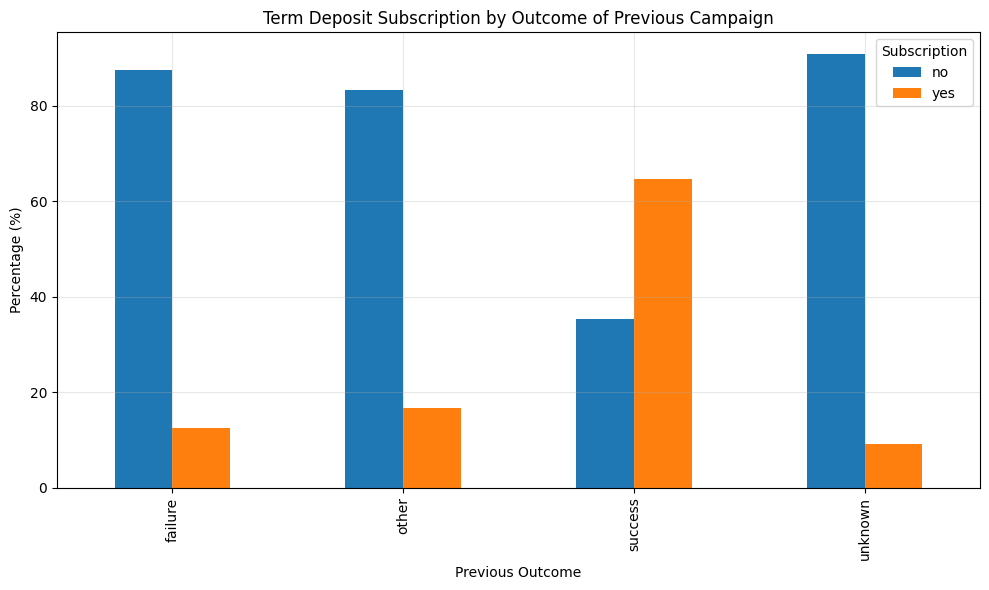

In [ ]:
plt.figure(figsize=(10, 6))
poutcome_subscription = pd.crosstab(df['poutcome'], df['y'])
poutcome_subscription_pct = poutcome_subscription.div(poutcome_subscription.sum(axis=1), axis=0) * 100

# Plot the percentage
poutcome_subscription_pct.plot(kind='bar', figsize=(10, 6))
plt.title('Term Deposit Subscription by Outcome of Previous Campaign')
plt.xlabel('Previous Outcome')
plt.ylabel('Percentage (%)')
plt.grid(True, alpha=0.3)
plt.legend(title='Subscription')
plt.tight_layout()
plt.show()

## Understanding data type and value for non-numerical data
This task is needed to understand what should be done in transforming the categorical variables before the dataset is fed into the model.

In [ ]:
# Show the data type for each feature in the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [ ]:
# Display the distribution of instances based on job of bank customers
df["job"].value_counts()

,count
job,
blue-collar,9732
management,9458
technician,7597
admin.,5171
services,4154
retired,2264
self-employed,1579
entrepreneur,1487
unemployed,1303


In [ ]:
# Show the distribution of instances based on marital status of bank customers
df["marital"].value_counts()

,count
marital,
married,27214
single,12790
divorced,5207


In [ ]:
# Display the distribution of instances based on latest education level of bank customers
df["education"].value_counts()

,count
education,
secondary,23202
tertiary,13301
primary,6851
unknown,1857


In [ ]:
# Show the distribution of instances based on credit default status of bank customers
df["default"].value_counts()

,count
default,
no,44396
yes,815


In [ ]:
# Show the distribution of instances based on housing loan status of bank customers
df["housing"].value_counts()

,count
housing,
yes,25130
no,20081


In [ ]:
# Display the distribution of instances based on personal loan status of bank customers
df["loan"].value_counts()

,count
loan,
no,37967
yes,7244


In [ ]:
# Show the distribution of instances based on preferred phone number of bank customers
df["contact"].value_counts()

,count
contact,
cellular,29285
unknown,13020
telephone,2906


In [ ]:
# Display the distribution of instances based on the outcome of previous marketing campaign
df["poutcome"].value_counts()

,count
poutcome,
unknown,36959
failure,4901
other,1840
success,1511


In [ ]:
# Display the distribution of instances based on the status of term deposit subscription after the current marketing campaign
df["y"].value_counts()

,count
y,
no,39922
yes,5289


## Age distribution of bank customers

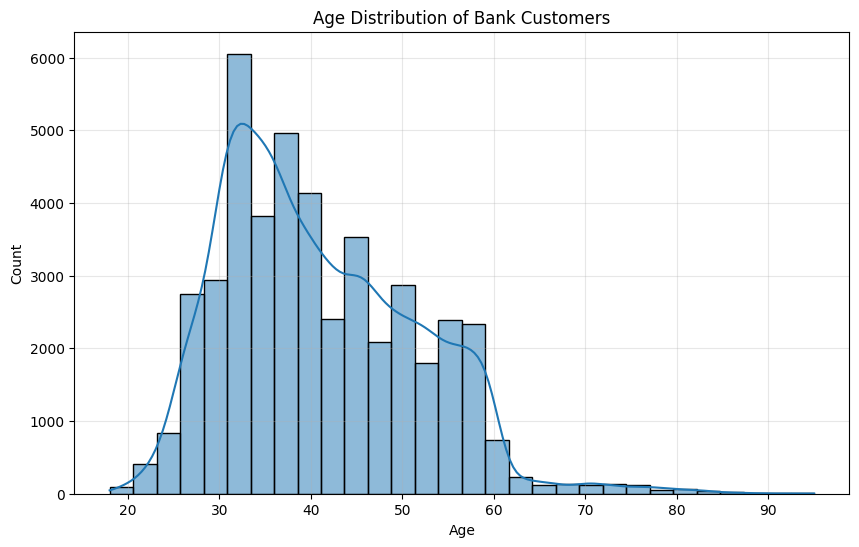

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['age'], bins=30, kde=True)
plt.title('Age Distribution of Bank Customers')
plt.xlabel('Age')
plt.ylabel('Count')
plt.grid(True, alpha=0.3)
plt.show()

## Term deposit subscription based on job

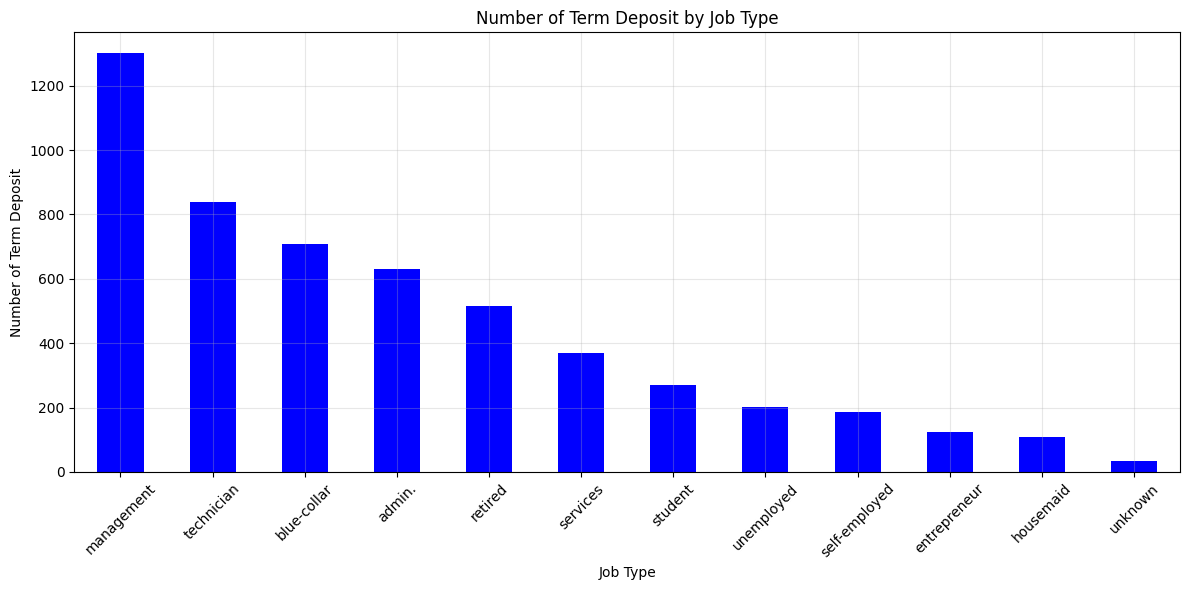

In [ ]:
yes_by_job = df[df['y'] == 'yes']['job'].value_counts().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
yes_by_job.plot(kind='bar', color='blue', figsize=(12, 6))
plt.title('Number of Term Deposit by Job Type')
plt.xlabel('Job Type')
plt.ylabel('Number of Term Deposit')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Term deposit subscription based on education

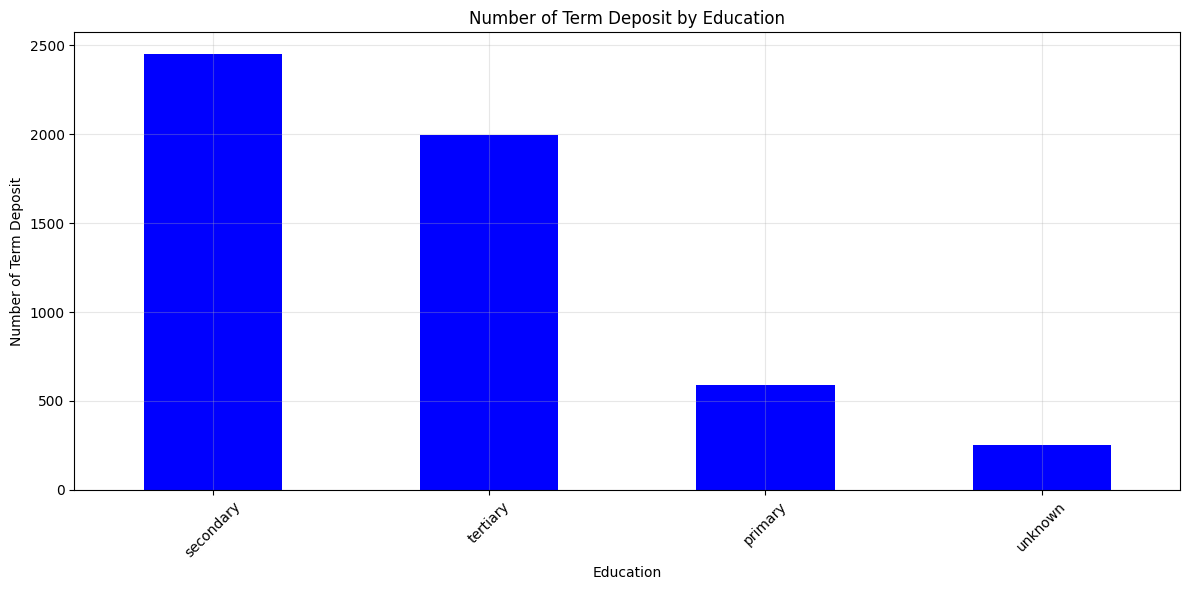

In [ ]:
yes_by_job = df[df['y'] == 'yes']['education'].value_counts().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
yes_by_job.plot(kind='bar', color='blue', figsize=(12, 6))
plt.title('Number of Term Deposit by Education')
plt.xlabel('Education')
plt.ylabel('Number of Term Deposit')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Neural network model development

## Multi Layer Perceptron

In [ ]:
# ===========================================================
# MLP Model with Standard Parameters
# ===========================================================
print("\n" + "="*50)
print("Training MLP Model with Standard Parameters")
print("="*50)

# Clean up memory
tf.keras.backend.clear_session()

# Create MLP model with standard parameters
mlp_standard_model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

# Compile model
mlp_standard_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.AUC()]
)

# Train model
mlp_standard_history = mlp_standard_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32,
    callbacks=[EarlyStopping(monitor='val_auc', mode='max', patience=5, restore_best_weights=True)],
    verbose=1
)

# Evaluate on test set
mlp_standard_y_pred_proba = mlp_standard_model.predict(X_test).ravel()
mlp_standard_y_pred = (mlp_standard_y_pred_proba > 0.5).astype(int)

# Calculate metrics
mlp_standard_accuracy = accuracy_score(y_test, mlp_standard_y_pred)
mlp_standard_auc = roc_auc_score(y_test, mlp_standard_y_pred_proba)
mlp_standard_loss = log_loss(y_test, mlp_standard_y_pred_proba)
mlp_standard_f1 = f1_score(y_test, mlp_standard_y_pred)

print("\nMLP Standard Model Test Metrics:")
print(f"Accuracy: {mlp_standard_accuracy:.4f}")
print(f"AUC: {mlp_standard_auc:.4f}")
print(f"Log Loss: {mlp_standard_loss:.4f}")
print(f"F1 Score: {mlp_standard_f1:.4f}")


Training MLP Model with Standard Parameters


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
848/848 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.7655 - auc: 0.6723 - loss: 0.5026 - val_accuracy: 0.8883 - val_auc: 0.8774 - val_loss: 0.2628
Epoch 2/20
848/848 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.8870 - auc: 0.8439 - loss: 0.2723 - val_accuracy: 0.8879 - val_auc: 0.8884 - val_loss: 0.2488
Epoch 3/20
848/848 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.8912 - auc: 0.8617 - loss: 0.2587 - val_accuracy: 0.8879 - val_auc: 0.8923 - val_loss: 0.2447
Epoch 4/20
848/848 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.8930 - auc: 0.8729 - loss: 0.2498 - val_accuracy: 0.8874 - val_auc: 0.8947 - val_loss: 0.2418
Epoch 5/20
848/848 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.8945 - auc: 0.8778 - loss: 0.2466 - val_accuracy: 0.8923 - val_auc: 0.8958 - val_loss: 0.2393
Epoch 6/20
848/848 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.8943 - auc: 0.8824 - loss: 0.2432 - val_accuracy: 0.8935 - val_auc: 0.8971 - val_loss: 0.2384
Epoch 7/20
848/848 ━━━━━━━━━━━━━━━━━━━━

## Wide & Deep model

In [ ]:
# ===========================================================
# Wide & Deep Model with Standard Parameters
# ===========================================================
print("\n" + "="*50)
print("Training Wide & Deep Model with Standard Parameters")
print("="*50)

# Clean up memory
tf.keras.backend.clear_session()

# Create Wide & Deep model with standard parameters
# Input layers
wide_input = Input(shape=(X_train.shape[1],))
deep_input = Input(shape=(X_train.shape[1],))

# Deep path
deep = Dense(64)(deep_input)
deep = BatchNormalization()(deep)
deep = Activation('relu')(deep)
deep = Dropout(0.3)(deep)

deep = Dense(32)(deep)
deep = BatchNormalization()(deep)
deep = Activation('relu')(deep)
deep = Dropout(0.2)(deep)

# Wide path
wide = Dense(32, activation='relu')(wide_input)

# Merge paths
merged = Concatenate()([wide, deep])
merged = Dense(16, activation='relu')(merged)
output = Dense(1, activation='sigmoid')(merged)

# Create and compile model
wide_deep_standard_model = Model(inputs=[wide_input, deep_input], outputs=output)
wide_deep_standard_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.AUC()]
)

# Train model
wide_deep_standard_history = wide_deep_standard_model.fit(
    [X_train, X_train],
    y_train,
    validation_data=([X_val, X_val], y_val),
    epochs=20,
    batch_size=32,
    callbacks=[EarlyStopping(monitor='val_auc', mode='max', patience=5, restore_best_weights=True)],
    verbose=1
)

# Evaluate on test set
wide_deep_standard_y_pred_proba = wide_deep_standard_model.predict([X_test, X_test]).ravel()
wide_deep_standard_y_pred = (wide_deep_standard_y_pred_proba > 0.5).astype(int)

# Calculate metrics
wide_deep_standard_accuracy = accuracy_score(y_test, wide_deep_standard_y_pred)
wide_deep_standard_auc = roc_auc_score(y_test, wide_deep_standard_y_pred_proba)
wide_deep_standard_loss = log_loss(y_test, wide_deep_standard_y_pred_proba)
wide_deep_standard_f1 = f1_score(y_test, wide_deep_standard_y_pred)

print("\nWide & Deep Standard Model Test Metrics:")
print(f"Accuracy: {wide_deep_standard_accuracy:.4f}")
print(f"AUC: {wide_deep_standard_auc:.4f}")
print(f"Log Loss: {wide_deep_standard_loss:.4f}")
print(f"F1 Score: {wide_deep_standard_f1:.4f}")


Training Wide & Deep Model with Standard Parameters
Epoch 1/20
848/848 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.8872 - auc: 0.8090 - loss: 0.2895 - val_accuracy: 0.8918 - val_auc: 0.8859 - val_loss: 0.2482
Epoch 2/20
848/848 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.8970 - auc: 0.8860 - loss: 0.2393 - val_accuracy: 0.8952 - val_auc: 0.8934 - val_loss: 0.2430
Epoch 3/20
848/848 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9017 - auc: 0.8945 - loss: 0.2318 - val_accuracy: 0.8987 - val_auc: 0.8968 - val_loss: 0.2398
Epoch 4/20
848/848 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9031 - auc: 0.8990 - loss: 0.2276 - val_accuracy: 0.8988 - val_auc: 0.8980 - val_loss: 0.2377
Epoch 5/20
848/848 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9038 - auc: 0.9020 - loss: 0.2244 - val_accuracy: 0.8970 - val_auc: 0.8993 - val_loss: 0.2372
Epoch 6/20
848/848 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9046 - auc: 0.9053 - loss: 0.2223 - val_accuracy: 0.8977 - val_auc: 0.9002 - val

## TabNet model

In [ ]:
# ===========================================================
# TabNet Model with Standard Parameters
# ===========================================================
print("\n" + "="*50)
print("Training TabNet Model with Standard Parameters")
print("="*50)

# Create TabNet model with standard parameters
tabnet_standard_model = TabNetClassifier(
    n_d=64,
    n_a=64,
    n_steps=5,
    gamma=1.5,
    n_independent=2,
    n_shared=2,
    momentum=0.3,
    lambda_sparse=1e-4,
    optimizer_fn=torch.optim.Adam,
    scheduler_params={"gamma": 0.95},
    scheduler_fn=torch.optim.lr_scheduler.ExponentialLR,
    mask_type='entmax',
    seed=42
)

# Train model
tabnet_standard_model.fit(
    X_train.values, y_train.values,
    eval_set=[(X_val.values, y_val.values)],
    eval_metric=['auc'],
    max_epochs=100,
    patience=10,
    batch_size=1024,
    virtual_batch_size=128,
    num_workers=0,
    drop_last=False,
)

# Evaluate on test set
tabnet_standard_y_pred = tabnet_standard_model.predict(X_test.values)
tabnet_standard_y_pred_proba = tabnet_standard_model.predict_proba(X_test.values)[:, 1]

# Calculate metrics
tabnet_standard_accuracy = accuracy_score(y_test, tabnet_standard_y_pred)
tabnet_standard_auc = roc_auc_score(y_test, tabnet_standard_y_pred_proba)
tabnet_standard_loss = log_loss(y_test, tabnet_standard_y_pred_proba)
tabnet_standard_f1 = f1_score(y_test, tabnet_standard_y_pred)

print("\nTabNet Standard Model Test Metrics:")
print(f"Accuracy: {tabnet_standard_accuracy:.4f}")
print(f"AUC: {tabnet_standard_auc:.4f}")
print(f"Log Loss: {tabnet_standard_loss:.4f}")
print(f"F1 Score: {tabnet_standard_f1:.4f}")


Training TabNet Model with Standard Parameters


/usr/local/lib/python3.11/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cuda
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 0.4552  | val_0_auc: 0.74031 |  0:00:03s
epoch 1  | loss: 0.29056 | val_0_auc: 0.81063 |  0:00:05s
epoch 2  | loss: 0.26751 | val_0_auc: 0.8518  |  0:00:07s
epoch 3  | loss: 0.26586 | val_0_auc: 0.8527  |  0:00:09s
epoch 4  | loss: 0.25675 | val_0_auc: 0.87317 |  0:00:11s
epoch 5  | loss: 0.25005 | val_0_auc: 0.88363 |  0:00:13s
epoch 6  | loss: 0.24455 | val_0_auc: 0.88084 |  0:00:15s
epoch 7  | loss: 0.24269 | val_0_auc: 0.89007 |  0:00:17s
epoch 8  | loss: 0.242   | val_0_auc: 0.88942 |  0:00:19s
epoch 9  | loss: 0.23825 | val_0_auc: 0.89379 |  0:00:21s
epoch 10 | loss: 0.2353  | val_0_auc: 0.89769 |  0:00:23s
epoch 11 | loss: 0.23284 | val_0_auc: 0.89956 |  0:00:25s
epoch 12 | loss: 0.23333 | val_0_auc: 0.8986  |  0:00:28s
epoch 13 | loss: 0.22806 | val_0_auc: 0.8985  |  0:00:30s
epoch 14 | loss: 0.23167 | val_0_auc: 0.90204 |  0:00:32s
epoch 15 | loss: 0.22758 | val_0_auc: 0.90278 |  0:00:34s
epoch 16 | loss: 0.22984 | val_0_auc: 0.90235 |  0:00:36s
epoch 17 | los

/usr/local/lib/python3.11/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)



TabNet Standard Model Test Metrics:
Accuracy: 0.9007
AUC: 0.9100
Log Loss: 0.2273
F1 Score: 0.5033


## Performance comparison

In [ ]:
# ===========================================================
# Compare Standard Models
# ===========================================================
print("\n" + "="*50)
print("Comparing Standard Models")
print("="*50)

# Store results for standard models
standard_results = {
    'mlp_standard_metrics': {
        'accuracy': float(mlp_standard_accuracy),
        'auc': float(mlp_standard_auc),
        'log_loss': float(mlp_standard_loss),
        'f1': float(mlp_standard_f1)
    },
    'wide_deep_standard_metrics': {
        'accuracy': float(wide_deep_standard_accuracy),
        'auc': float(wide_deep_standard_auc),
        'log_loss': float(wide_deep_standard_loss),
        'f1': float(wide_deep_standard_f1)
    },
    'tabnet_standard_metrics': {
        'accuracy': float(tabnet_standard_accuracy),
        'auc': float(tabnet_standard_auc),
        'log_loss': float(tabnet_standard_loss),
        'f1': float(tabnet_standard_f1)
    }
}

# Plot comparison of standard models
metrics = ['accuracy', 'auc', 'f1']
mlp_standard_scores = [mlp_standard_accuracy, mlp_standard_auc, mlp_standard_f1]
wide_deep_standard_scores = [wide_deep_standard_accuracy, wide_deep_standard_auc, wide_deep_standard_f1]
tabnet_standard_scores = [tabnet_standard_accuracy, tabnet_standard_auc, tabnet_standard_f1]

plt.figure(figsize=(10, 6))
x = np.arange(len(metrics))
width = 0.25

plt.bar(x - width, mlp_standard_scores, width, label='MLP')
plt.bar(x, wide_deep_standard_scores, width, label='Wide & Deep')
plt.bar(x + width, tabnet_standard_scores, width, label='TabNet')

plt.ylabel('Score')
plt.title('Standard Model Comparison')
plt.xticks(x, metrics)
plt.legend()
plt.ylim(0, 1.0)

plt.tight_layout()
plt.savefig('standard_model_comparison.png')
plt.close()


Comparing Standard Models


In [ ]:
# Display results
result_initial = pd.DataFrame({
    'Model': ['MLP', 'Wide & Deep', 'TabNet'],
    'Accuracy': [mlp_standard_accuracy, wide_deep_standard_accuracy, tabnet_standard_accuracy],
    'Log Loss': [mlp_standard_loss, wide_deep_standard_loss, tabnet_standard_loss],
    'F1 Score': [mlp_standard_f1, wide_deep_standard_f1, tabnet_standard_f1]
})

display(result_initial)

,Model,Accuracy,Log Loss,F1 Score
0,MLP,0.895499,0.236098,0.385166
1,Wide & Deep,0.898043,0.235842,0.454438
2,TabNet,0.900697,0.227282,0.503319


# Neural network model improvement

## Model tuning using Bayesian optimization

### Tuning on TabNet

In [ ]:
# ===========================================================
# TabNet Bayesian Optimization
# ===========================================================
print("\n" + "="*50)
print("Starting TabNet Model Bayesian Optimization")
print("="*50)

n_opt_steps = 15  # Number of optimization steps

# Define TabNet parameter space
tabnet_space = [
    Integer(8, 128, name='n_d'),
    Integer(8, 128, name='n_a'),
    Integer(3, 10, name='n_steps'),
    Real(1.0, 2.0, name='gamma'),
    Integer(1, 5, name='n_independent'),
    Integer(1, 5, name='n_shared'),
    Real(0.01, 0.9, name='momentum'),
    Real(1e-5, 1e-3, "log-uniform", name='lambda_sparse'),
    Integer(512, 2048, name='batch_size'),  # Ensure this range is appropriate
    Integer(64, 256, name='virtual_batch_size'),
    Integer(50, 150, name='max_epochs')
]

# TabNet early stopping class
class TabNetEarlyStoppingCallback:
    def __init__(self, patience=5):
        self.patience = patience
        self.best_auc = 0
        self.counter = 0

    def __call__(self, validation_metrics):
        current_auc = validation_metrics['auc']
        if current_auc > self.best_auc:
            self.best_auc = current_auc
            self.counter = 0
            return False
        else:
            self.counter += 1
            return self.counter >= self.patience

@use_named_args(tabnet_space)
def tabnet_objective(**params):
    """Objective function for TabNet optimization"""
    # Fix batch_size handling - convert to int and ensure positive
    batch_size = int(params['batch_size'])
    if batch_size <= 0:
        batch_size = 512  # Default to minimum if somehow negative

    # Fix virtual_batch_size handling
    virtual_batch_size = int(params['virtual_batch_size'])
    if virtual_batch_size <= 0:
        virtual_batch_size = 64  # Default to minimum if somehow negative

    # Ensure virtual_batch_size <= batch_size
    virtual_batch_size = min(virtual_batch_size, batch_size)

    # Update params with corrected values
    params['batch_size'] = batch_size
    params['virtual_batch_size'] = virtual_batch_size

    # Create TabNet model
    model = TabNetClassifier(
        n_d=int(params['n_d']),
        n_a=int(params['n_a']),
        n_steps=int(params['n_steps']),
        gamma=float(params['gamma']),
        n_independent=int(params['n_independent']),
        n_shared=int(params['n_shared']),
        momentum=float(params['momentum']),
        lambda_sparse=float(params['lambda_sparse']),
        optimizer_fn=torch.optim.Adam,
        scheduler_params={"gamma": 0.95},
        scheduler_fn=torch.optim.lr_scheduler.ExponentialLR,
        mask_type='entmax',
        seed=42
    )

    try:
        # Train the model
        model.fit(
            X_train.values, y_train.values,
            eval_set=[(X_val.values, y_val.values)],
            eval_metric=['auc'],
            max_epochs=int(params['max_epochs']),
            patience=5,  # Faster early stopping
            batch_size=batch_size,  # Use the corrected batch_size
            virtual_batch_size=virtual_batch_size,  # Use the corrected virtual_batch_size
            num_workers=0,
            drop_last=False,
            callbacks=[TabNetEarlyStoppingCallback(patience=3)]
        )

        # Predict on validation set
        y_pred_proba = model.predict_proba(X_val.values)[:, 1]
        auc = roc_auc_score(y_val, y_pred_proba)

        # We want to maximize AUC, so return negative AUC for minimization
        return -auc

    except Exception as e:
        print(f"Error in TabNet training: {e}")
        return -0.5  # Return a poor score in case of error

# Run TabNet Bayesian optimization
tabnet_start_time = time.time()

tabnet_result = gp_minimize(
    func=tabnet_objective,
    dimensions=tabnet_space,
    n_calls=n_opt_steps,
    n_initial_points=5,
    random_state=42,
    verbose=True
)

# Print best parameters and score
print("\nBest TabNet Parameters:")
tabnet_param_names = [dim.name for dim in tabnet_space]
tabnet_best_params = {}
for param_name, param_value in zip(tabnet_param_names, tabnet_result.x):
    # Ensure integer parameters are properly converted
    if param_name in ['n_d', 'n_a', 'n_steps', 'n_independent', 'n_shared',
                       'batch_size', 'virtual_batch_size', 'max_epochs']:
        param_value = int(param_value)
    tabnet_best_params[param_name] = param_value
    print(f"{param_name}: {param_value}")

print(f"Best AUC: {-tabnet_result.fun:.4f}")
print(f"Optimization time: {(time.time() - tabnet_start_time) / 60:.2f} minutes")


Starting TabNet Model Bayesian Optimization
Iteration No: 1 started. Evaluating function at random point.
Error in TabNet training: 'TabNetEarlyStoppingCallback' object has no attribute 'set_trainer'
Iteration No: 1 ended. Evaluation done at random point.
Time taken: 0.0581
Function value obtained: -0.5000
Current minimum: -0.5000
Iteration No: 2 started. Evaluating function at random point.
Error in TabNet training: 'TabNetEarlyStoppingCallback' object has no attribute 'set_trainer'
Iteration No: 2 ended. Evaluation done at random point.
Time taken: 0.0537
Function value obtained: -0.5000
Current minimum: -0.5000
Iteration No: 3 started. Evaluating function at random point.
Error in TabNet training: 'TabNetEarlyStoppingCallback' object has no attribute 'set_trainer'
Iteration No: 3 ended. Evaluation done at random point.
Time taken: 0.0625
Function value obtained: -0.5000
Current minimum: -0.5000
Iteration No: 4 started. Evaluating function at random point.


/usr/local/lib/python3.11/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cuda
  warnings.warn(f"Device used : {self.device}")
/usr/local/lib/python3.11/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cuda
  warnings.warn(f"Device used : {self.device}")
/usr/local/lib/python3.11/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cuda
  warnings.warn(f"Device used : {self.device}")
/usr/local/lib/python3.11/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cuda
  warnings.warn(f"Device used : {self.device}")


Error in TabNet training: 'TabNetEarlyStoppingCallback' object has no attribute 'set_trainer'
Iteration No: 4 ended. Evaluation done at random point.
Time taken: 0.0572
Function value obtained: -0.5000
Current minimum: -0.5000
Iteration No: 5 started. Evaluating function at random point.
Error in TabNet training: 'TabNetEarlyStoppingCallback' object has no attribute 'set_trainer'


/usr/local/lib/python3.11/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cuda
  warnings.warn(f"Device used : {self.device}")


Iteration No: 5 ended. Evaluation done at random point.
Time taken: 0.5993
Function value obtained: -0.5000
Current minimum: -0.5000
Iteration No: 6 started. Searching for the next optimal point.
Error in TabNet training: 'TabNetEarlyStoppingCallback' object has no attribute 'set_trainer'


...

Iteration No: 13 ended. Search finished for the next optimal point.
Time taken: 0.4205
Function value obtained: -0.5000
Current minimum: -0.5000
Iteration No: 14 started. Searching for the next optimal point.
Error in TabNet training: 'TabNetEarlyStoppingCallback' object has no attribute 'set_trainer'


/usr/local/lib/python3.11/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cuda
  warnings.warn(f"Device used : {self.device}")


Iteration No: 14 ended. Search finished for the next optimal point.
Time taken: 0.4339
Function value obtained: -0.5000
Current minimum: -0.5000
Iteration No: 15 started. Searching for the next optimal point.
Error in TabNet training: 'TabNetEarlyStoppingCallback' object has no attribute 'set_trainer'


/usr/local/lib/python3.11/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cuda
  warnings.warn(f"Device used : {self.device}")


Iteration No: 15 ended. Search finished for the next optimal point.
Time taken: 0.4445
Function value obtained: -0.5000
Current minimum: -0.5000

Best TabNet Parameters:
n_d: 104
n_a: 30
n_steps: 8
gamma: 1.596850157946487
n_independent: 3
n_shared: 1
momentum: 0.4187315138496219
lambda_sparse: 4.649617447336329e-05
batch_size: 731
virtual_batch_size: 189
max_epochs: 56
Best AUC: 0.5000
Optimization time: 0.09 minutes


In [ ]:
# ===========================================================
# Train and Evaluate Optimized TabNet Model
# ===========================================================
print("\n" + "="*50)
print("Training Optimized TabNet Model with Best Parameters")
print("="*50)

# Combine train and validation sets for final training
X_train_full = pd.concat([X_train, X_val])
y_train_full = pd.concat([y_train, y_val])

# Extract parameters
params = tabnet_best_params

# Ensure batch_size is a positive integer
batch_size = int(params['batch_size'])
if batch_size <= 0:
    batch_size = 512

# Ensure virtual_batch_size is a positive integer <= batch_size
virtual_batch_size = int(params['virtual_batch_size'])
if virtual_batch_size <= 0:
    virtual_batch_size = 64
virtual_batch_size = min(virtual_batch_size, batch_size)

# Create model with best parameters
tabnet_optimized_model = TabNetClassifier(
    n_d=int(params['n_d']),
    n_a=int(params['n_a']),
    n_steps=int(params['n_steps']),
    gamma=float(params['gamma']),
    n_independent=int(params['n_independent']),
    n_shared=int(params['n_shared']),
    momentum=float(params['momentum']),
    lambda_sparse=float(params['lambda_sparse']),
    optimizer_fn=torch.optim.Adam,
    scheduler_params={"gamma": 0.95},
    scheduler_fn=torch.optim.lr_scheduler.ExponentialLR,
    mask_type='entmax',
    seed=42
)

# Train model
tabnet_optimized_model.fit(
    X_train_full.values, y_train_full.values,
    eval_set=[(X_test.values, y_test.values)],
    eval_metric=['auc'],
    max_epochs=int(params['max_epochs']),
    patience=15,
    batch_size=batch_size,  # Use corrected batch_size
    virtual_batch_size=virtual_batch_size,  # Use corrected virtual_batch_size
    num_workers=0,
    drop_last=False
)

# Evaluate on test set
tabnet_optimized_y_pred = tabnet_optimized_model.predict(X_test.values)
tabnet_optimized_y_pred_proba = tabnet_optimized_model.predict_proba(X_test.values)[:, 1]

# Calculate metrics
tabnet_optimized_accuracy = accuracy_score(y_test, tabnet_optimized_y_pred)
tabnet_optimized_auc = roc_auc_score(y_test, tabnet_optimized_y_pred_proba)
tabnet_optimized_loss = log_loss(y_test, tabnet_optimized_y_pred_proba)
tabnet_optimized_f1 = f1_score(y_test, tabnet_optimized_y_pred)

print("\nOptimized TabNet Test Metrics:")
print(f"Accuracy: {tabnet_optimized_accuracy:.4f}")
print(f"AUC: {tabnet_optimized_auc:.4f}")
print(f"Log Loss: {tabnet_optimized_loss:.4f}")
print(f"F1 Score: {tabnet_optimized_f1:.4f}")


Training Optimized TabNet Model with Best Parameters


/usr/local/lib/python3.11/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cuda
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 0.8725  | val_0_auc: 0.72956 |  0:00:04s
epoch 1  | loss: 0.32013 | val_0_auc: 0.80358 |  0:00:08s
epoch 2  | loss: 0.30397 | val_0_auc: 0.83358 |  0:00:12s
epoch 3  | loss: 0.2724  | val_0_auc: 0.84879 |  0:00:17s
epoch 4  | loss: 0.26724 | val_0_auc: 0.8531  |  0:00:21s
epoch 5  | loss: 0.26401 | val_0_auc: 0.85866 |  0:00:25s
epoch 6  | loss: 0.25544 | val_0_auc: 0.87138 |  0:00:29s
epoch 7  | loss: 0.25356 | val_0_auc: 0.8702  |  0:00:33s
epoch 8  | loss: 0.25512 | val_0_auc: 0.87021 |  0:00:37s
epoch 9  | loss: 0.25151 | val_0_auc: 0.87367 |  0:00:41s
epoch 10 | loss: 0.24839 | val_0_auc: 0.87841 |  0:00:46s
epoch 11 | loss: 0.24685 | val_0_auc: 0.87584 |  0:00:50s
epoch 12 | loss: 0.24886 | val_0_auc: 0.87942 |  0:00:54s
epoch 13 | loss: 0.2456  | val_0_auc: 0.8801  |  0:00:58s
epoch 14 | loss: 0.24193 | val_0_auc: 0.88711 |  0:01:02s
epoch 15 | loss: 0.24085 | val_0_auc: 0.88875 |  0:01:06s
epoch 16 | loss: 0.24069 | val_0_auc: 0.88598 |  0:01:10s
epoch 17 | los

/usr/local/lib/python3.11/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)



Optimized TabNet Test Metrics:
Accuracy: 0.8982
AUC: 0.9025
Log Loss: 0.2353
F1 Score: 0.4776


In [ ]:
# Display results
result_after_tuning = pd.DataFrame({
    'Model': ['MLP', 'Wide & Deep', 'TabNet', 'TabNet (after tuning)'],
    'Accuracy': [mlp_standard_accuracy, wide_deep_standard_accuracy, tabnet_standard_accuracy, tabnet_optimized_accuracy],
    'Log Loss': [mlp_standard_loss, wide_deep_standard_loss, tabnet_standard_loss, tabnet_optimized_loss],
    'F1 Score': [mlp_standard_f1, wide_deep_standard_f1, tabnet_standard_f1, tabnet_optimized_f1]
})

display(result_after_tuning)

,Model,Accuracy,Log Loss,F1 Score
0,MLP,0.895499,0.236098,0.385166
1,Wide & Deep,0.898043,0.235842,0.454438
2,TabNet,0.900697,0.227282,0.503319
3,TabNet (after tuning),0.898153,0.235267,0.477595


### Tuning on Wide & Deep

In [ ]:
# ===========================================================
# Wide & Deep Bayesian Optimization
# ===========================================================
print("\n" + "="*50)
print("Starting Wide & Deep Model Bayesian Optimization")
print("="*50)

# Define the search space for the Wide & Deep model
wide_deep_space = [
    Integer(16, 128, name='wide_units'),
    Integer(32, 256, name='deep_units_1'),
    Integer(16, 128, name='deep_units_2'),
    Real(0.1, 0.5, name='deep_dropout_1'),
    Real(0.1, 0.5, name='deep_dropout_2'),
    Real(0.0001, 0.01, "log-uniform", name='learning_rate'),
    Integer(8, 64, name='merged_units')
]

@use_named_args(wide_deep_space)
def wide_deep_objective(**params):
    """Objective function for Wide & Deep model optimization"""

    # Clean up memory
    tf.keras.backend.clear_session()

    # Create model with given hyperparameters
    wide_input = Input(shape=(X_train.shape[1],))
    deep_input = Input(shape=(X_train.shape[1],))

    # Deep path
    deep = Dense(params['deep_units_1'])(deep_input)
    deep = BatchNormalization()(deep)
    deep = Activation('relu')(deep)
    deep = Dropout(params['deep_dropout_1'])(deep)

    deep = Dense(params['deep_units_2'])(deep)
    deep = BatchNormalization()(deep)
    deep = Activation('relu')(deep)
    deep = Dropout(params['deep_dropout_2'])(deep)

    # Wide path
    wide = Dense(params['wide_units'], activation='relu')(wide_input)

    # Merge paths
    merged = Concatenate()([wide, deep])
    merged = Dense(params['merged_units'], activation='relu')(merged)
    output = Dense(1, activation='sigmoid')(merged)

    model = Model(inputs=[wide_input, deep_input], outputs=output)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=params['learning_rate']),
        loss='binary_crossentropy',
        metrics=['accuracy', keras.metrics.AUC()]
    )

    # Define callbacks
    callbacks = [
        EarlyStopping(monitor='val_auc', mode='max', patience=5, restore_best_weights=True)
    ]

    try:
        # Train the model
        history = model.fit(
            [X_train, X_train],
            y_train,
            epochs=20,
            batch_size=256,
            validation_data=([X_val, X_val], y_val),
            callbacks=callbacks,
            verbose=0
        )

        # Predict on validation set
        y_pred_proba = model.predict([X_val, X_val]).ravel()
        auc = roc_auc_score(y_val, y_pred_proba)

        # We want to maximize AUC, so return negative AUC for minimization
        return -auc

    except Exception as e:
        print(f"Error in model training: {e}")
        # Return a poor score in case of error
        return -0.5

# Run Wide & Deep Bayesian optimization
wide_deep_start_time = time.time()

wide_deep_result = gp_minimize(
    func=wide_deep_objective,
    dimensions=wide_deep_space,
    n_calls=n_opt_steps,
    n_initial_points=5,
    random_state=42,
    verbose=True
)

# Print best parameters and score
print("\nBest Wide & Deep Parameters:")
wide_deep_param_names = [dim.name for dim in wide_deep_space]
wide_deep_best_params = {}
for param_name, param_value in zip(wide_deep_param_names, wide_deep_result.x):
    wide_deep_best_params[param_name] = param_value
    print(f"{param_name}: {param_value}")

print(f"Best AUC: {-wide_deep_result.fun:.4f}")
print(f"Optimization time: {(time.time() - wide_deep_start_time) / 60:.2f} minutes")

# Plot convergence
plt.figure(figsize=(10, 6))
plot_convergence(wide_deep_result)
plt.savefig('wide_deep_convergence.png')
plt.close()

# Save best parameters to JSON
with open('wide_deep_best_params.json', 'w') as f:
    # Convert numeric types to Python builtin types for JSON serialization
    serializable_params = {k: float(v) if isinstance(v, (np.float32, np.float64))
                          else int(v) if isinstance(v, np.integer) else v
                          for k, v in wide_deep_best_params.items()}
    json.dump(serializable_params, f, indent=2)


Starting Wide & Deep Model Bayesian Optimization
Iteration No: 1 started. Evaluating function at random point.
283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Iteration No: 1 ended. Evaluation done at random point.
Time taken: 22.5855
Function value obtained: -0.8994
Current minimum: -0.8994
Iteration No: 2 started. Evaluating function at random point.
283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Iteration No: 2 ended. Evaluation done at random point.
Time taken: 20.5506
Function value obtained: -0.9145
Current minimum: -0.9145
Iteration No: 3 started. Evaluating function at random point.
283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Iteration No: 3 ended. Evaluation done at random point.
Time taken: 22.3887
Function value obtained: -0.9157
Current minimum: -0.9157
Iteration No: 4 started. Evaluating function at random point.
283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Iteration No: 4 ended. Evaluation done at random point.
Time taken: 22.4160
Function value obtained: -0.9100
Current minimum: -0.9157
It

In [ ]:
# ===========================================================
# Train and Evaluate Final Wide & Deep Model
# ===========================================================
print("\n" + "="*50)
print("Training Final Wide & Deep Model with Best Parameters")
print("="*50)

# Clean up memory
tf.keras.backend.clear_session()

# Extract parameters
params = wide_deep_best_params

# Create model with best parameters
wide_input = Input(shape=(X_train.shape[1],))
deep_input = Input(shape=(X_train.shape[1],))

# Deep path
deep = Dense(params['deep_units_1'])(deep_input)
deep = BatchNormalization()(deep)
deep = Activation('relu')(deep)
deep = Dropout(params['deep_dropout_1'])(deep)

deep = Dense(params['deep_units_2'])(deep)
deep = BatchNormalization()(deep)
deep = Activation('relu')(deep)
deep = Dropout(params['deep_dropout_2'])(deep)

# Wide path
wide = Dense(params['wide_units'], activation='relu')(wide_input)

# Merge paths
merged = Concatenate()([wide, deep])
merged = Dense(params['merged_units'], activation='relu')(merged)
output = Dense(1, activation='sigmoid')(merged)

wide_deep_model = Model(inputs=[wide_input, deep_input], outputs=output)
wide_deep_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=params['learning_rate']),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.AUC()]
)

# Define callbacks
callbacks = [
    EarlyStopping(monitor='val_auc', mode='max', patience=10, restore_best_weights=True),
    ModelCheckpoint('best_wide_deep_model.h5', monitor='val_auc', mode='max', save_best_only=True)
]

# Train model
wide_deep_history = wide_deep_model.fit(
    [X_train_full, X_train_full],
    y_train_full,
    epochs=50,
    batch_size=256,
    validation_data=([X_test, X_test], y_test),
    callbacks=callbacks,
    verbose=1
)

# Evaluate on test set
wide_deep_y_pred_proba = wide_deep_model.predict([X_test, X_test]).ravel()
wide_deep_y_pred = (wide_deep_y_pred_proba > 0.5).astype(int)

# Calculate metrics
wide_deep_accuracy = accuracy_score(y_test, wide_deep_y_pred)
wide_deep_auc = roc_auc_score(y_test, wide_deep_y_pred_proba)
wide_deep_loss = log_loss(y_test, wide_deep_y_pred_proba)
wide_deep_f1 = f1_score(y_test, wide_deep_y_pred)

print("\nWide & Deep Test Metrics:")
print(f"Accuracy: {wide_deep_accuracy:.4f}")
print(f"AUC: {wide_deep_auc:.4f}")
print(f"Log Loss: {wide_deep_loss:.4f}")
print(f"F1 Score: {wide_deep_f1:.4f}")


Training Final Wide & Deep Model with Best Parameters
Epoch 1/50
141/142 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8828 - auc: 0.8272 - loss: 0.2796

142/142 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.8828 - auc: 0.8278 - loss: 0.2793 - val_accuracy: 0.8813 - val_auc: 0.8709 - val_loss: 0.2732
Epoch 2/50
141/142 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8920 - auc: 0.8885 - loss: 0.2385

142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8920 - auc: 0.8885 - loss: 0.2385 - val_accuracy: 0.8830 - val_auc: 0.8930 - val_loss: 0.2520
Epoch 3/50
135/142 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8991 - auc: 0.8962 - loss: 0.2316

142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8991 - auc: 0.8963 - loss: 0.2316 - val_accuracy: 0.8909 - val_auc: 0.8998 - val_loss: 0.2396
Epoch 4/50
139/142 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9019 - auc: 0.9010 - loss: 0.2276

142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9019 - auc: 0.9010 - loss: 0.2276 - val_accuracy: 0.8927 - val_auc: 0.9019 - val_loss: 0.2414
Epoch 5/50
136/142 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9016 - auc: 0.9038 - loss: 0.2250

...

142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9059 - auc: 0.9205 - loss: 0.2092 - val_accuracy: 0.9007 - val_auc: 0.9127 - val_loss: 0.2243
Epoch 14/50
141/142 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9075 - auc: 0.9229 - loss: 0.2068

142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9075 - auc: 0.9229 - loss: 0.2069 - val_accuracy: 0.8986 - val_auc: 0.9162 - val_loss: 0.2209
Epoch 15/50
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9069 - auc: 0.9243 - loss: 0.2057 - val_accuracy: 0.9017 - val_auc: 0.9155 - val_loss: 0.2204
Epoch 16/50
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9069 - auc: 0.9246 - loss: 0.2054 - val_accuracy: 0.8976 - val_auc: 0.9159 - val_loss: 0.2201
Epoch 17/50
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9073 - auc: 0.9253 - loss: 0.2042 - val_accuracy: 0.8994 - val_auc: 0.9136 - val_loss: 0.2226
Epoch 18/50
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9096 - auc: 0.9269 - loss: 0.2023 - val_accuracy: 0.8986 - val_auc: 0.9150 - val_loss: 0.2205
Epoch 19/50
139/142 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9079 - auc: 0.9271 - loss: 0.2021

142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9079 - auc: 0.9271 - loss: 0.2021 - val_accuracy: 0.8984 - val_auc: 0.9191 - val_loss: 0.2161
Epoch 20/50
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9093 - auc: 0.9288 - loss: 0.1998

142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9093 - auc: 0.9288 - loss: 0.1998 - val_accuracy: 0.9006 - val_auc: 0.9191 - val_loss: 0.2154
Epoch 21/50
140/142 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9080 - auc: 0.9288 - loss: 0.2003

142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9080 - auc: 0.9288 - loss: 0.2003 - val_accuracy: 0.8997 - val_auc: 0.9210 - val_loss: 0.2137
Epoch 22/50
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9095 - auc: 0.9296 - loss: 0.1995 - val_accuracy: 0.8985 - val_auc: 0.9175 - val_loss: 0.2176
Epoch 23/50
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9093 - auc: 0.9318 - loss: 0.1967 - val_accuracy: 0.9004 - val_auc: 0.9179 - val_loss: 0.2189
Epoch 24/50
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9101 - auc: 0.9316 - loss: 0.1965 - val_accuracy: 0.8998 - val_auc: 0.9176 - val_loss: 0.2168
Epoch 25/50
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9112 - auc: 0.9336 - loss: 0.1938 - val_accuracy: 0.9010 - val_auc: 0.9183 - val_loss: 0.2203
Epoch 26/50
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9114 - auc: 0.9333 - loss: 0.1939 - val_accuracy: 0.9011 - val_auc: 0.9183 - val_loss: 0.2175
Epoch 27/50
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 8m

In [ ]:
# Display results
result_after_tuning = pd.DataFrame({
    'Model': ['MLP', 'Wide & Deep', 'TabNet', 'TabNet (after tuning)', 'Wide & Deep (after tuning)'],
    'Accuracy': [mlp_standard_accuracy, wide_deep_standard_accuracy, tabnet_standard_accuracy, tabnet_optimized_accuracy, wide_deep_accuracy],
    'Log Loss': [mlp_standard_loss, wide_deep_standard_loss, tabnet_standard_loss, tabnet_optimized_loss, wide_deep_loss],
    'F1 Score': [mlp_standard_f1, wide_deep_standard_f1, tabnet_standard_f1, tabnet_optimized_f1, wide_deep_f1]
})

display(result_after_tuning)

,Model,Accuracy,Log Loss,F1 Score
0,MLP,0.895499,0.236098,0.385166
1,Wide & Deep,0.898043,0.235842,0.454438
2,TabNet,0.900697,0.227282,0.503319
3,TabNet (after tuning),0.898153,0.235267,0.477595
4,Wide & Deep (after tuning),0.899701,0.213686,0.562047


### Tuning on Multi Layer Perceptron

In [ ]:
# ===========================================================
# MLP Bayesian Optimization
# ===========================================================
print("\n" + "="*50)
print("Starting MLP Model Bayesian Optimization")
print("="*50)

# Define search space for MLP
mlp_space = [
    Integer(32, 256, name='hidden_layer_1_units'),
    Integer(16, 128, name='hidden_layer_2_units'),
    Categorical([0, 1], name='add_third_layer'),
    Integer(8, 64, name='hidden_layer_3_units'),
    Real(0.1, 0.5, name='dropout_1'),
    Real(0.1, 0.5, name='dropout_2'),
    Real(0.0001, 0.01, "log-uniform", name='learning_rate'),
    Categorical(['relu', 'elu', 'selu'], name='activation'),
    Integer(16, 512, name='batch_size')
]

@use_named_args(mlp_space)
def mlp_objective(**params):
    """Objective function for MLP optimization"""

    # Clean up memory
    tf.keras.backend.clear_session()

    # Create model
    model = Sequential()
    model.add(Dense(params['hidden_layer_1_units'],
                   input_shape=(X_train.shape[1],),
                   activation=params['activation']))
    model.add(BatchNormalization())
    model.add(Dropout(params['dropout_1']))

    model.add(Dense(params['hidden_layer_2_units'], activation=params['activation']))
    model.add(BatchNormalization())
    model.add(Dropout(params['dropout_2']))

    # Add optional third layer
    if params['add_third_layer'] == 1:
        model.add(Dense(params['hidden_layer_3_units'], activation=params['activation']))
        model.add(BatchNormalization())
        model.add(Dropout(params['dropout_2']))  # Reuse same dropout rate

    model.add(Dense(1, activation='sigmoid'))

    # Compile model
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=params['learning_rate']),
        loss='binary_crossentropy',
        metrics=['accuracy', keras.metrics.AUC()]
    )

    # Early stopping
    early_stop = EarlyStopping(monitor='val_auc', mode='max', patience=5, restore_best_weights=True)

    try:
        # Train model
        history = model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=30,
            batch_size=params['batch_size'],
            callbacks=[early_stop],
            verbose=0
        )

        # Evaluate on validation set
        y_pred_proba = model.predict(X_val).ravel()
        auc = roc_auc_score(y_val, y_pred_proba)

        # Return negative AUC for minimization
        return -auc

    except Exception as e:
        print(f"Error in MLP training: {e}")
        return -0.5

# Run MLP Bayesian optimization
mlp_start_time = time.time()
n_opt_steps = 15  # Number of optimization steps

mlp_result = gp_minimize(
    func=mlp_objective,
    dimensions=mlp_space,
    n_calls=n_opt_steps,
    n_initial_points=5,
    random_state=42,
    verbose=True
)

# Print best parameters and score
print("\nBest MLP Parameters:")
mlp_param_names = [dim.name for dim in mlp_space]
mlp_best_params = {}
for param_name, param_value in zip(mlp_param_names, mlp_result.x):
    mlp_best_params[param_name] = param_value
    print(f"{param_name}: {param_value}")

print(f"Best AUC: {-mlp_result.fun:.4f}")
print(f"Optimization time: {(time.time() - mlp_start_time) / 60:.2f} minutes")

# Plot convergence
plt.figure(figsize=(10, 6))
plot_convergence(mlp_result)
plt.savefig('mlp_convergence.png')
plt.close()

# Save best parameters to JSON
with open('mlp_best_params.json', 'w') as f:
    # Convert numeric types to Python builtin types for JSON serialization
    serializable_params = {k: float(v) if isinstance(v, (np.float32, np.float64))
                          else int(v) if isinstance(v, np.integer) else v
                          for k, v in mlp_best_params.items()}
    json.dump(serializable_params, f, indent=2)


Starting MLP Model Bayesian Optimization
Iteration No: 1 started. Evaluating function at random point.


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Iteration No: 1 ended. Evaluation done at random point.
Time taken: 81.5441
Function value obtained: -0.9077
Current minimum: -0.9077
Iteration No: 2 started. Evaluating function at random point.


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Iteration No: 2 ended. Evaluation done at random point.
Time taken: 241.1651
Function value obtained: -0.9028
Current minimum: -0.9077
Iteration No: 3 started. Evaluating function at random point.


...

283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Iteration No: 13 ended. Search finished for the next optimal point.
Time taken: 43.2073
Function value obtained: -0.9050
Current minimum: -0.9193
Iteration No: 14 started. Searching for the next optimal point.


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Iteration No: 14 ended. Search finished for the next optimal point.
Time taken: 23.5521
Function value obtained: -0.9069
Current minimum: -0.9193
Iteration No: 15 started. Searching for the next optimal point.


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Iteration No: 15 ended. Search finished for the next optimal point.
Time taken: 24.6263
Function value obtained: -0.9086
Current minimum: -0.9193

Best MLP Parameters:
hidden_layer_1_units: 252
hidden_layer_2_units: 68
add_third_layer: 1
hidden_layer_3_units: 46
dropout_1: 0.28019970078781725
dropout_2: 0.10530598446394662
learning_rate: 0.0076630826802558585
activation: elu
batch_size: 207
Best AUC: 0.9193
Optimization time: 17.36 minutes


In [ ]:
# ===========================================================
# Train and Evaluate Final MLP Model
# ===========================================================
print("\n" + "="*50)
print("Training Final MLP Model with Best Parameters")
print("="*50)

# Clean up memory
tf.keras.backend.clear_session()

# Extract parameters
params = mlp_best_params

# Create model with best parameters
mlp_model = Sequential()
mlp_model.add(Dense(params['hidden_layer_1_units'],
                   input_shape=(X_train.shape[1],),
                   activation=params['activation']))
mlp_model.add(BatchNormalization())
mlp_model.add(Dropout(params['dropout_1']))

mlp_model.add(Dense(params['hidden_layer_2_units'], activation=params['activation']))
mlp_model.add(BatchNormalization())
mlp_model.add(Dropout(params['dropout_2']))

# Add optional third layer
if params['add_third_layer'] == 1:
    mlp_model.add(Dense(params['hidden_layer_3_units'], activation=params['activation']))
    mlp_model.add(BatchNormalization())
    mlp_model.add(Dropout(params['dropout_2']))

mlp_model.add(Dense(1, activation='sigmoid'))

# Compile model
mlp_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=params['learning_rate']),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.AUC()]
)

# Define callbacks
callbacks = [
    EarlyStopping(monitor='val_auc', mode='max', patience=10, restore_best_weights=True),
    ModelCheckpoint('best_mlp_model.h5', monitor='val_auc', mode='max', save_best_only=True)
]

# Combine train and validation sets for final training
X_train_full = pd.concat([X_train, X_val])
y_train_full = pd.concat([y_train, y_val])

# Train model
mlp_history = mlp_model.fit(
    X_train_full,
    y_train_full,
    epochs=50,
    batch_size=params['batch_size'],
    validation_data=(X_test, y_test),
    callbacks=callbacks,
    verbose=1
)

# Evaluate on test set
mlp_y_pred_proba = mlp_model.predict(X_test).ravel()
mlp_y_pred = (mlp_y_pred_proba > 0.5).astype(int)

# Calculate metrics
mlp_accuracy = accuracy_score(y_test, mlp_y_pred)
mlp_auc = roc_auc_score(y_test, mlp_y_pred_proba)
mlp_loss = log_loss(y_test, mlp_y_pred_proba)
mlp_f1 = f1_score(y_test, mlp_y_pred)

print("\nMLP Test Metrics:")
print(f"Accuracy: {mlp_accuracy:.4f}")
print(f"AUC: {mlp_auc:.4f}")
print(f"Log Loss: {mlp_loss:.4f}")
print(f"F1 Score: {mlp_f1:.4f}")


Training Final MLP Model with Best Parameters
Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8398 - auc: 0.7755 - loss: 0.3900

175/175 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.8400 - auc: 0.7758 - loss: 0.3895 - val_accuracy: 0.8884 - val_auc: 0.8777 - val_loss: 0.2561
Epoch 2/50
170/175 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8933 - auc: 0.8785 - loss: 0.2473

175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8933 - auc: 0.8787 - loss: 0.2472 - val_accuracy: 0.8919 - val_auc: 0.8898 - val_loss: 0.2466
Epoch 3/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8963 - auc: 0.8882 - loss: 0.2389

...

175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9084 - auc: 0.9252 - loss: 0.2037 - val_accuracy: 0.9017 - val_auc: 0.9183 - val_loss: 0.2174
Epoch 24/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9080 - auc: 0.9264 - loss: 0.2019 - val_accuracy: 0.9027 - val_auc: 0.9169 - val_loss: 0.2184
Epoch 25/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9086 - auc: 0.9267 - loss: 0.2023 - val_accuracy: 0.9015 - val_auc: 0.9153 - val_loss: 0.2201
Epoch 26/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9086 - auc: 0.9286 - loss: 0.2004 - val_accuracy: 0.9015 - val_auc: 0.9168 - val_loss: 0.2187
Epoch 27/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9097 - auc: 0.9277 - loss: 0.2012 - val_accuracy: 0.9004 - val_auc: 0.9177 - val_loss: 0.2177
Epoch 28/50
170/175 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9112 - auc: 0.9293 - loss: 0.1990

175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9111 - auc: 0.9293 - loss: 0.1990 - val_accuracy: 0.9006 - val_auc: 0.9203 - val_loss: 0.2153
Epoch 29/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9116 - auc: 0.9317 - loss: 0.1961 - val_accuracy: 0.9021 - val_auc: 0.9183 - val_loss: 0.2172
Epoch 30/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9095 - auc: 0.9303 - loss: 0.1980

175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9095 - auc: 0.9303 - loss: 0.1980 - val_accuracy: 0.9017 - val_auc: 0.9204 - val_loss: 0.2161
Epoch 31/50
172/175 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9123 - auc: 0.9313 - loss: 0.1971

175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9122 - auc: 0.9313 - loss: 0.1971 - val_accuracy: 0.9029 - val_auc: 0.9224 - val_loss: 0.2134
Epoch 32/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9113 - auc: 0.9331 - loss: 0.1947 - val_accuracy: 0.9012 - val_auc: 0.9206 - val_loss: 0.2164
Epoch 33/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9117 - auc: 0.9313 - loss: 0.1960 - val_accuracy: 0.9024 - val_auc: 0.9178 - val_loss: 0.2178
Epoch 34/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9118 - auc: 0.9320 - loss: 0.1960 - val_accuracy: 0.9030 - val_auc: 0.9204 - val_loss: 0.2156
Epoch 35/50
169/175 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9125 - auc: 0.9351 - loss: 0.1919

175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9125 - auc: 0.9350 - loss: 0.1920 - val_accuracy: 0.9014 - val_auc: 0.9235 - val_loss: 0.2133
Epoch 36/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9132 - auc: 0.9360 - loss: 0.1911 - val_accuracy: 0.8989 - val_auc: 0.9207 - val_loss: 0.2186
Epoch 37/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9135 - auc: 0.9358 - loss: 0.1915 - val_accuracy: 0.9022 - val_auc: 0.9211 - val_loss: 0.2151
Epoch 38/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9134 - auc: 0.9354 - loss: 0.1913 - val_accuracy: 0.9021 - val_auc: 0.9196 - val_loss: 0.2164
Epoch 39/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9132 - auc: 0.9375 - loss: 0.1891 - val_accuracy: 0.9019 - val_auc: 0.9200 - val_loss: 0.2161
Epoch 40/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9150 - auc: 0.9372 - loss: 0.1888 - val_accuracy: 0.9046 - val_auc: 0.9225 - val_loss: 0.2151
Epoch 41/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 8m

In [ ]:
# Display results
result_after_tuning = pd.DataFrame({
    'Model': ['MLP', 'Wide & Deep', 'TabNet', 'TabNet (after tuning)', 'Wide & Deep (after tuning)', 'MLP (after tuning)'],
    'Accuracy': [mlp_standard_accuracy, wide_deep_standard_accuracy, tabnet_standard_accuracy, tabnet_optimized_accuracy, wide_deep_accuracy, mlp_accuracy],
    'Log Loss': [mlp_standard_loss, wide_deep_standard_loss, tabnet_standard_loss, tabnet_optimized_loss, wide_deep_loss, mlp_loss],
    'F1 Score': [mlp_standard_f1, wide_deep_standard_f1, tabnet_standard_f1, tabnet_optimized_f1, wide_deep_f1, mlp_f1]
})

display(result_after_tuning)

,Model,Accuracy,Log Loss,F1 Score
0,MLP,0.895499,0.236098,0.385166
1,Wide & Deep,0.898043,0.235842,0.454438
2,TabNet,0.900697,0.227282,0.503319
3,TabNet (after tuning),0.898153,0.235267,0.477595
4,Wide & Deep (after tuning),0.899701,0.213686,0.562047
5,MLP (after tuning),0.901360,0.213320,0.576448


## Ensemble using bagging approach

### Bagging on optimized Multi Layer Perceptron

In [ ]:
# Bagging Ensemble for best MLP model
print("\n" + "="*50)
print("Creating Bagging Ensemble with MLP Model")
print("="*50)

# Number of bagged models
n_models = 5  # Start with 5 models for reasonable computation time

# Extract parameters
params = mlp_best_params

# Storage for models and predictions
bag_models = []
bag_predictions = []
sample_size = int(len(X_train_full) * 0.8)  # 80% bootstrap sample

# Train individual bagged models
for i in range(n_models):
    print(f"Training bagged model {i+1}/{n_models}")

    # Clean up memory
    tf.keras.backend.clear_session()

    # Bootstrap sampling (with replacement)
    indices = np.random.choice(len(X_train_full), sample_size, replace=True)
    X_boot = X_train_full.iloc[indices]
    y_boot = y_train_full.iloc[indices]

    # Create model with best parameters
    bagged_model = Sequential()
    bagged_model.add(Dense(params['hidden_layer_1_units'],
                         input_shape=(X_train_full.shape[1],),
                         activation=params['activation']))
    bagged_model.add(BatchNormalization())
    bagged_model.add(Dropout(params['dropout_1']))

    bagged_model.add(Dense(params['hidden_layer_2_units'], activation=params['activation']))
    bagged_model.add(BatchNormalization())
    bagged_model.add(Dropout(params['dropout_2']))

    # Add optional third layer
    if params['add_third_layer'] == 1:
        bagged_model.add(Dense(params['hidden_layer_3_units'], activation=params['activation']))
        bagged_model.add(BatchNormalization())
        bagged_model.add(Dropout(params['dropout_2']))

    bagged_model.add(Dense(1, activation='sigmoid'))

    # Compile model
    bagged_model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=params['learning_rate']),
        loss='binary_crossentropy',
        metrics=['accuracy', keras.metrics.AUC()]
    )

    # Train with early stopping
    bagged_model.fit(
        X_boot, y_boot,
        epochs=20,  # Reduced for faster training
        batch_size=params['batch_size'],
        callbacks=[EarlyStopping(monitor='loss', patience=3)],  # Simpler early stopping
        verbose=1
    )

    bag_models.append(bagged_model)

    # Get predictions
    preds = bagged_model.predict(X_test).ravel()
    bag_predictions.append(preds)

# Average predictions
bag_predictions = np.array(bag_predictions)
bagging_predictions = np.mean(bag_predictions, axis=0)
bagging_binary_predictions = (bagging_predictions > 0.5).astype(int)

# Calculate metrics
bagging_accuracy = accuracy_score(y_test, bagging_binary_predictions)
bagging_logloss = log_loss(y_test, bagging_predictions)
bagging_f1 = f1_score(y_test, bagging_binary_predictions)

print("\nBagging Ensemble Metrics:")
print(f"Accuracy: {bagging_accuracy:.6f}")
print(f"Log Loss: {bagging_logloss:.6f}")
print(f"F1 Score: {bagging_f1:.6f}")


Creating Bagging Ensemble with MLP Model
Training bagged model 1/5
Epoch 1/20


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


140/140 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8248 - auc: 0.7777 - loss: 0.4066
Epoch 2/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8894 - auc: 0.8755 - loss: 0.2541
Epoch 3/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8911 - auc: 0.8845 - loss: 0.2460
Epoch 4/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8925 - auc: 0.8883 - loss: 0.2423
Epoch 5/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8934 - auc: 0.8908 - loss: 0.2403
Epoch 6/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8938 - auc: 0.8950 - loss: 0.2371
Epoch 7/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8972 - auc: 0.9001 - loss: 0.2325
Epoch 8/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8950 - auc: 0.9001 - loss: 0.2328
Epoch 9/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8980 - auc: 0.9064 - loss: 0.2269
Epoch 10/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8992 - auc: 0.9061 - loss: 0.2275
Epoch 11/2

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


140/140 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8069 - auc: 0.7617 - loss: 0.4344
Epoch 2/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8835 - auc: 0.8704 - loss: 0.2673
Epoch 3/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8896 - auc: 0.8808 - loss: 0.2573
Epoch 4/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8874 - auc: 0.8847 - loss: 0.2533
Epoch 5/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8901 - auc: 0.8889 - loss: 0.2501
Epoch 6/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8921 - auc: 0.8926 - loss: 0.2464
Epoch 7/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8945 - auc: 0.8949 - loss: 0.2443
Epoch 8/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8931 - auc: 0.8966 - loss: 0.2429
Epoch 9/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8929 - auc: 0.8979 - loss: 0.2413
Epoch 10/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8947 - auc: 0.8997 - loss: 0.2397
Epoch 11/2

...

140/140 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8210 - auc: 0.7611 - loss: 0.4100
Epoch 2/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8908 - auc: 0.8757 - loss: 0.2524
Epoch 3/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8959 - auc: 0.8869 - loss: 0.2427
Epoch 4/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8961 - auc: 0.8935 - loss: 0.2369
Epoch 5/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8980 - auc: 0.8975 - loss: 0.2333
Epoch 6/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8998 - auc: 0.8981 - loss: 0.2319
Epoch 7/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9007 - auc: 0.9038 - loss: 0.2273
Epoch 8/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9012 - auc: 0.9046 - loss: 0.2266
Epoch 9/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9023 - auc: 0.9068 - loss: 0.2242
Epoch 10/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9009 - auc: 0.9086 - loss: 0.2230
Epoch 11/2

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


140/140 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8138 - auc: 0.7481 - loss: 0.4487
Epoch 2/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8890 - auc: 0.8782 - loss: 0.2525
Epoch 3/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8936 - auc: 0.8907 - loss: 0.2408
Epoch 4/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8972 - auc: 0.8962 - loss: 0.2355
Epoch 5/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8979 - auc: 0.8994 - loss: 0.2328
Epoch 6/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8975 - auc: 0.9018 - loss: 0.2309
Epoch 7/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9000 - auc: 0.9068 - loss: 0.2254
Epoch 8/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8984 - auc: 0.9064 - loss: 0.2265
Epoch 9/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8997 - auc: 0.9118 - loss: 0.2210
Epoch 10/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9020 - auc: 0.9128 - loss: 0.2194
Epoch 11/2

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


140/140 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8221 - auc: 0.7756 - loss: 0.4213
Epoch 2/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8927 - auc: 0.8805 - loss: 0.2487
Epoch 3/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8955 - auc: 0.8898 - loss: 0.2403
Epoch 4/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8953 - auc: 0.8949 - loss: 0.2358
Epoch 5/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8983 - auc: 0.9008 - loss: 0.2311
Epoch 6/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9000 - auc: 0.9036 - loss: 0.2279
Epoch 7/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9002 - auc: 0.9049 - loss: 0.2270
Epoch 8/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9014 - auc: 0.9097 - loss: 0.2225
Epoch 9/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9019 - auc: 0.9110 - loss: 0.2207
Epoch 10/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9041 - auc: 0.9145 - loss: 0.2175
Epoch 11/2

In [ ]:
# Display results
result_after_tuning_ensemble = pd.DataFrame({
    'Model': ['MLP', 'Wide & Deep', 'TabNet', 'TabNet (after tuning)', 'Wide & Deep (after tuning)', 'MLP (after tuning)', 'MLP (after tuning and bagging ensemble)'],
    'Accuracy': [mlp_standard_accuracy, wide_deep_standard_accuracy, tabnet_standard_accuracy, tabnet_optimized_accuracy, wide_deep_accuracy, mlp_accuracy, bagging_accuracy],
    'Log Loss': [mlp_standard_loss, wide_deep_standard_loss, tabnet_standard_loss, tabnet_optimized_loss, wide_deep_loss, mlp_loss, bagging_logloss],
    'F1 Score': [mlp_standard_f1, wide_deep_standard_f1, tabnet_standard_f1, tabnet_optimized_f1, wide_deep_f1, mlp_f1, bagging_f1]
})

display(result_after_tuning_ensemble)

,Model,Accuracy,Log Loss,F1 Score
0,MLP,0.895499,0.236098,0.385166
1,Wide & Deep,0.898043,0.235842,0.454438
2,TabNet,0.900697,0.227282,0.503319
3,TabNet (after tuning),0.898153,0.235267,0.477595
4,Wide & Deep (after tuning),0.899701,0.213686,0.562047
5,MLP (after tuning),0.901360,0.213320,0.576448
6,MLP (after tuning and bagging ensemble),0.899923,0.221098,0.476576


### Bagging on optimized Wide & Deep

In [ ]:
# Bagging Ensemble for Wide & Deep Model
print("\n" + "="*50)
print("Creating Bagging Ensemble with Wide & Deep Model")
print("="*50)

# Number of bagged models
n_models = 5  # Adjust based on computational resources

# Extract parameters from the optimized Wide & Deep model
params = wide_deep_best_params

# Storage for models and predictions
wide_deep_bag_models = []
wide_deep_bag_predictions = []
sample_size = int(len(X_train_full) * 0.8)  # 80% bootstrap sample

# Train individual bagged models
for i in range(n_models):
    print(f"Training Wide & Deep bagged model {i+1}/{n_models}")

    # Clean up memory
    tf.keras.backend.clear_session()

    # Bootstrap sampling (with replacement)
    indices = np.random.choice(len(X_train_full), sample_size, replace=True)
    X_boot = X_train_full.iloc[indices]
    y_boot = y_train_full.iloc[indices]

    # Create Wide & Deep model with best parameters
    # Input layers
    wide_input = Input(shape=(X_train_full.shape[1],))
    deep_input = Input(shape=(X_train_full.shape[1],))

    # Deep path
    deep = Dense(params['deep_units_1'])(deep_input)
    deep = BatchNormalization()(deep)
    deep = Activation('relu')(deep)
    deep = Dropout(params['deep_dropout_1'])(deep)

    deep = Dense(params['deep_units_2'])(deep)
    deep = BatchNormalization()(deep)
    deep = Activation('relu')(deep)
    deep = Dropout(params['deep_dropout_2'])(deep)

    # Wide path
    wide = Dense(params['wide_units'], activation='relu')(wide_input)

    # Merge paths
    merged = Concatenate()([wide, deep])
    merged = Dense(params['merged_units'], activation='relu')(merged)
    output = Dense(1, activation='sigmoid')(merged)

    # Create and compile model
    bagged_wide_deep_model = Model(inputs=[wide_input, deep_input], outputs=output)
    bagged_wide_deep_model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=params['learning_rate']),
        loss='binary_crossentropy',
        metrics=['accuracy', keras.metrics.AUC()]
    )

    # Train model with early stopping
    callbacks = [
        EarlyStopping(monitor='loss', mode='min', patience=3, restore_best_weights=True)
    ]

    bagged_wide_deep_model.fit(
        [X_boot, X_boot],
        y_boot,
        epochs=15,  # Reduced for faster training
        batch_size=256,
        callbacks=callbacks,
        verbose=1
    )

    wide_deep_bag_models.append(bagged_wide_deep_model)

    # Get predictions on test set
    preds = bagged_wide_deep_model.predict([X_test, X_test]).ravel()
    wide_deep_bag_predictions.append(preds)

# Average predictions from all bagged models
wide_deep_bag_predictions = np.array(wide_deep_bag_predictions)
wide_deep_bagging_predictions = np.mean(wide_deep_bag_predictions, axis=0)
wide_deep_bagging_binary_predictions = (wide_deep_bagging_predictions > 0.5).astype(int)

# Calculate metrics
wide_deep_bagging_accuracy = accuracy_score(y_test, wide_deep_bagging_binary_predictions)
wide_deep_bagging_auc = roc_auc_score(y_test, wide_deep_bagging_predictions)
wide_deep_bagging_loss = log_loss(y_test, wide_deep_bagging_predictions)
wide_deep_bagging_f1 = f1_score(y_test, wide_deep_bagging_binary_predictions)

print("\nWide & Deep Bagging Ensemble Test Metrics:")
print(f"Accuracy: {wide_deep_bagging_accuracy:.4f}")
print(f"AUC: {wide_deep_bagging_auc:.4f}")
print(f"Log Loss: {wide_deep_bagging_loss:.4f}")
print(f"F1 Score: {wide_deep_bagging_f1:.4f}")


Creating Bagging Ensemble with Wide & Deep Model
Training Wide & Deep bagged model 1/5
Epoch 1/15
114/114 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8620 - auc: 0.7795 - loss: 0.3215
Epoch 2/15
114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8893 - auc: 0.8872 - loss: 0.2405
Epoch 3/15
114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8959 - auc: 0.8944 - loss: 0.2339
Epoch 4/15
114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8984 - auc: 0.9030 - loss: 0.2268
Epoch 5/15
114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9017 - auc: 0.9077 - loss: 0.2223
Epoch 6/15
114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9028 - auc: 0.9101 - loss: 0.2198
Epoch 7/15
114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9036 - auc: 0.9124 - loss: 0.2173
Epoch 8/15
114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9047 - auc: 0.9163 - loss: 0.2134
Epoch 9/15
114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9040 - auc: 0.9165 - loss: 0.2130
Epoch 10/15


In [ ]:
# Display results
result_after_tuning_ensemble = pd.DataFrame({
    'Model': ['MLP', 'Wide & Deep', 'TabNet', 'TabNet (after tuning)', 'Wide & Deep (after tuning)', 'MLP (after tuning)', 'MLP (after tuning and bagging ensemble)', 'Wide & Deep (after tuning and bagging ensemble)'],
    'Accuracy': [mlp_standard_accuracy, wide_deep_standard_accuracy, tabnet_standard_accuracy, tabnet_optimized_accuracy, wide_deep_accuracy, mlp_accuracy, bagging_accuracy, wide_deep_bagging_accuracy],
    'Log Loss': [mlp_standard_loss, wide_deep_standard_loss, tabnet_standard_loss, tabnet_optimized_loss, wide_deep_loss, mlp_loss, bagging_logloss, wide_deep_bagging_loss],
    'F1 Score': [mlp_standard_f1, wide_deep_standard_f1, tabnet_standard_f1, tabnet_optimized_f1, wide_deep_f1, mlp_f1, bagging_f1, wide_deep_bagging_f1]
})

display(result_after_tuning_ensemble)

,Model,Accuracy,Log Loss,F1 Score
0,MLP,0.895499,0.236098,0.385166
1,Wide & Deep,0.898043,0.235842,0.454438
2,TabNet,0.900697,0.227282,0.503319
3,TabNet (after tuning),0.898153,0.235267,0.477595
4,Wide & Deep (after tuning),0.899701,0.213686,0.562047
5,MLP (after tuning),0.901360,0.213320,0.576448
6,MLP (after tuning and bagging ensemble),0.899923,0.221098,0.476576
7,Wide & Deep (after tuning and bagging ensemble),0.899259,0.222313,0.494170


### Bagging on optimized TabNet

In [ ]:
# Bagging Ensemble for Optimized TabNet Model
print("\n" + "="*50)
print("Creating Bagging Ensemble with Optimized TabNet Model")
print("="*50)

# Number of TabNet models in the bagging ensemble
n_models = 5  # Adjust based on computational resources

# Extract parameters from the optimized TabNet model
# Use the same parameters that were found through Bayesian optimization
tabnet_params = {
    'n_d': 104,
    'n_a': 30,
    'n_steps': 8,
    'gamma': 1.596850157946487,
    'n_independent': 3,
    'n_shared': 1,
    'momentum': 0.4187315138496219,
    'lambda_sparse': 4.649617447336329e-05,
    'batch_size': 731,
    'virtual_batch_size': 189,
    'max_epochs': 56
}

# Storage for models and predictions
tabnet_bag_models = []
tabnet_bag_predictions = []
sample_size = int(len(X_train_full) * 0.8)  # 80% bootstrap sample

# Train individual bagged TabNet models
for i in range(n_models):
    print(f"Training TabNet bagged model {i+1}/{n_models}")

    # Bootstrap sampling (with replacement)
    indices = np.random.choice(len(X_train_full), sample_size, replace=True)
    X_boot = X_train_full.iloc[indices]
    y_boot = y_train_full.iloc[indices]

    # Create TabNet model with best parameters
    tabnet_bagged_model = TabNetClassifier(
        n_d=tabnet_params['n_d'],
        n_a=tabnet_params['n_a'],
        n_steps=tabnet_params['n_steps'],
        gamma=tabnet_params['gamma'],
        n_independent=tabnet_params['n_independent'],
        n_shared=tabnet_params['n_shared'],
        momentum=tabnet_params['momentum'],
        lambda_sparse=tabnet_params['lambda_sparse'],
        optimizer_fn=torch.optim.Adam,
        scheduler_params={"gamma": 0.95},
        scheduler_fn=torch.optim.lr_scheduler.ExponentialLR,
        mask_type='entmax',
        seed=42 + i  # Different seed for each model to increase diversity
    )

    # Train TabNet model
    tabnet_bagged_model.fit(
        X_boot.values, y_boot.values,
        eval_set=[(X_test.values, y_test.values)],
        eval_metric=['auc'],
        max_epochs=tabnet_params['max_epochs'],
        patience=10,
        batch_size=tabnet_params['batch_size'],
        virtual_batch_size=tabnet_params['virtual_batch_size'],
        num_workers=0,
        drop_last=False
    )

    tabnet_bag_models.append(tabnet_bagged_model)

    # Get predictions on test set
    preds = tabnet_bagged_model.predict_proba(X_test.values)[:, 1]
    tabnet_bag_predictions.append(preds)

# Average predictions from all bagged models
tabnet_bag_predictions = np.array(tabnet_bag_predictions)
tabnet_bagging_predictions = np.mean(tabnet_bag_predictions, axis=0)
tabnet_bagging_binary_predictions = (tabnet_bagging_predictions > 0.5).astype(int)

# Calculate metrics
tabnet_bagging_accuracy = accuracy_score(y_test, tabnet_bagging_binary_predictions)
tabnet_bagging_auc = roc_auc_score(y_test, tabnet_bagging_predictions)
tabnet_bagging_loss = log_loss(y_test, tabnet_bagging_predictions)
tabnet_bagging_f1 = f1_score(y_test, tabnet_bagging_binary_predictions)

print("\nTabNet Bagging Ensemble Test Metrics:")
print(f"Accuracy: {tabnet_bagging_accuracy:.4f}")
print(f"AUC: {tabnet_bagging_auc:.4f}")
print(f"Log Loss: {tabnet_bagging_loss:.4f}")
print(f"F1 Score: {tabnet_bagging_f1:.4f}")


Creating Bagging Ensemble with Optimized TabNet Model
Training TabNet bagged model 1/5


/usr/local/lib/python3.11/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cuda
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 0.67179 | val_0_auc: 0.69206 |  0:00:03s
epoch 1  | loss: 0.35867 | val_0_auc: 0.80607 |  0:00:06s
epoch 2  | loss: 0.26453 | val_0_auc: 0.81955 |  0:00:10s
epoch 3  | loss: 0.26982 | val_0_auc: 0.83039 |  0:00:13s
epoch 4  | loss: 0.26576 | val_0_auc: 0.86689 |  0:00:16s
epoch 5  | loss: 0.26445 | val_0_auc: 0.85744 |  0:00:20s
epoch 6  | loss: 0.25611 | val_0_auc: 0.86886 |  0:00:23s
epoch 7  | loss: 0.25829 | val_0_auc: 0.86327 |  0:00:27s
epoch 8  | loss: 0.25586 | val_0_auc: 0.8722  |  0:00:30s
epoch 9  | loss: 0.24564 | val_0_auc: 0.8741  |  0:00:34s
epoch 10 | loss: 0.24477 | val_0_auc: 0.88202 |  0:00:37s
epoch 11 | loss: 0.24641 | val_0_auc: 0.88323 |  0:00:40s
epoch 12 | loss: 0.2455  | val_0_auc: 0.88127 |  0:00:44s
epoch 13 | loss: 0.24066 | val_0_auc: 0.88437 |  0:00:47s
epoch 14 | loss: 0.23698 | val_0_auc: 0.88584 |  0:00:51s
epoch 15 | loss: 0.23718 | val_0_auc: 0.88516 |  0:00:54s
epoch 16 | loss: 0.23615 | val_0_auc: 0.88557 |  0:00:58s
epoch 17 | los

/usr/local/lib/python3.11/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


Training TabNet bagged model 2/5


...

Training TabNet bagged model 5/5


/usr/local/lib/python3.11/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cuda
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 0.69719 | val_0_auc: 0.69898 |  0:00:03s
epoch 1  | loss: 0.40391 | val_0_auc: 0.75674 |  0:00:06s
epoch 2  | loss: 0.29537 | val_0_auc: 0.81078 |  0:00:10s
epoch 3  | loss: 0.28261 | val_0_auc: 0.85169 |  0:00:13s
epoch 4  | loss: 0.26726 | val_0_auc: 0.86034 |  0:00:17s
epoch 5  | loss: 0.26571 | val_0_auc: 0.86095 |  0:00:20s
epoch 6  | loss: 0.26855 | val_0_auc: 0.86144 |  0:00:23s
epoch 7  | loss: 0.27162 | val_0_auc: 0.85791 |  0:00:27s
epoch 8  | loss: 0.26818 | val_0_auc: 0.86568 |  0:00:30s
epoch 9  | loss: 0.26371 | val_0_auc: 0.8675  |  0:00:34s
epoch 10 | loss: 0.25731 | val_0_auc: 0.87425 |  0:00:37s
epoch 11 | loss: 0.25467 | val_0_auc: 0.8743  |  0:00:41s
epoch 12 | loss: 0.25218 | val_0_auc: 0.87499 |  0:00:44s
epoch 13 | loss: 0.24724 | val_0_auc: 0.87918 |  0:00:48s
epoch 14 | loss: 0.24956 | val_0_auc: 0.87849 |  0:00:51s
epoch 15 | loss: 0.25085 | val_0_auc: 0.87615 |  0:00:54s
epoch 16 | loss: 0.24828 | val_0_auc: 0.88256 |  0:00:58s
epoch 17 | los

/usr/local/lib/python3.11/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)



TabNet Bagging Ensemble Test Metrics:
Accuracy: 0.9001
AUC: 0.9066
Log Loss: 0.2305
F1 Score: 0.4570


In [ ]:
# Display results
result_after_tuning_ensemble = pd.DataFrame({
    'Model': ['MLP', 'Wide & Deep', 'TabNet', 'TabNet (after tuning)', 'Wide & Deep (after tuning)', 'MLP (after tuning)', 'MLP (after tuning and bagging ensemble)', 'Wide & Deep (after tuning and bagging ensemble)', 'TabNet (after tuning and bagging ensemble)'],
    'Accuracy': [mlp_standard_accuracy, wide_deep_standard_accuracy, tabnet_standard_accuracy, tabnet_optimized_accuracy, wide_deep_accuracy, mlp_accuracy, bagging_accuracy, wide_deep_bagging_accuracy, tabnet_bagging_accuracy],
    'Log Loss': [mlp_standard_loss, wide_deep_standard_loss, tabnet_standard_loss, tabnet_optimized_loss, wide_deep_loss, mlp_loss, bagging_logloss, wide_deep_bagging_loss, tabnet_bagging_loss],
    'F1 Score': [mlp_standard_f1, wide_deep_standard_f1, tabnet_standard_f1, tabnet_optimized_f1, wide_deep_f1, mlp_f1, bagging_f1, wide_deep_bagging_f1, tabnet_bagging_f1]
})

display(result_after_tuning_ensemble)

,Model,Accuracy,Log Loss,F1 Score
0,MLP,0.895499,0.236098,0.385166
1,Wide & Deep,0.898043,0.235842,0.454438
2,TabNet,0.900697,0.227282,0.503319
3,TabNet (after tuning),0.898153,0.235267,0.477595
4,Wide & Deep (after tuning),0.899701,0.213686,0.562047
5,MLP (after tuning),0.901360,0.213320,0.576448
6,MLP (after tuning and bagging ensemble),0.899923,0.221098,0.476576
7,Wide & Deep (after tuning and bagging ensemble),0.899259,0.222313,0.494170
8,TabNet (after tuning and bagging ensemble),0.900144,0.230458,0.457005


## Ensemble using stacking method

In [ ]:
# Stacked ensemble
# Stacked Ensemble with Multiple Meta-Learners
print("\n" + "="*50)
print("Comparing Different Meta-Learners for Stacked Ensemble")
print("="*50)

# Import necessary libraries
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression, RidgeClassifier
import xgboost as xgb
from sklearn.neural_network import MLPClassifier

# Collect base model predictions on validation set
base_preds_val = []

# MLP model predictions
mlp_val_preds = mlp_model.predict(X_val).ravel()
base_preds_val.append(mlp_val_preds)

# Wide & Deep model predictions
wide_deep_val_preds = wide_deep_model.predict([X_val, X_val]).ravel()
base_preds_val.append(wide_deep_val_preds)

# TabNet model predictions
tabnet_val_preds = tabnet_optimized_model.predict_proba(X_val.values)[:, 1]
base_preds_val.append(tabnet_val_preds)

# Stack validation predictions
base_preds_val = np.column_stack(base_preds_val)

# Collect base model predictions on test set
base_preds_test = []

# MLP model predictions
mlp_test_preds = mlp_model.predict(X_test).ravel()
base_preds_test.append(mlp_test_preds)

# Wide & Deep model predictions
wide_deep_test_preds = wide_deep_model.predict([X_test, X_test]).ravel()
base_preds_test.append(wide_deep_test_preds)

# TabNet model predictions
tabnet_test_preds = tabnet_optimized_model.predict_proba(X_test.values)[:, 1]
base_preds_test.append(tabnet_test_preds)

# Stack test predictions
base_preds_test = np.column_stack(base_preds_test)

# Define multiple meta-learners
meta_learners = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    'SVM': SVC(probability=True, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'Neural Network': MLPClassifier(hidden_layer_sizes=(10,5), max_iter=1000, random_state=42),
    'Naive Bayes': GaussianNB(),
    'Ridge Classifier': RidgeClassifier(random_state=42)
}

# Train and evaluate each meta-learner
meta_results = {}
best_meta_learner = None
best_meta_f1 = 0

for name, meta_model in meta_learners.items():
    print(f"Training {name} meta-learner...")

    # Train on validation predictions
    meta_model.fit(base_preds_val, y_val)

    # Predict on test set
    meta_preds = meta_model.predict(base_preds_test)

    # Handle meta-learners that may not have predict_proba
    if hasattr(meta_model, 'predict_proba'):
        meta_preds_proba = meta_model.predict_proba(base_preds_test)[:, 1]
    else:
        # For models without predict_proba, use decision function if available or fall back
        if hasattr(meta_model, 'decision_function'):
            meta_preds_proba = meta_model.decision_function(base_preds_test)
            # Normalize to [0,1] range
            meta_preds_proba = (meta_preds_proba - meta_preds_proba.min()) / (meta_preds_proba.max() - meta_preds_proba.min())
        else:
            # Fall back to binary predictions
            meta_preds_proba = meta_preds

    # Calculate metrics
    meta_accuracy = accuracy_score(y_test, meta_preds)
    meta_auc = roc_auc_score(y_test, meta_preds_proba)
    meta_loss = log_loss(y_test, meta_preds_proba)
    meta_f1 = f1_score(y_test, meta_preds)

    meta_results[name] = {
        'accuracy': meta_accuracy,
        'auc': meta_auc,
        'log_loss': meta_loss,
        'f1': meta_f1
    }

    # Track best meta-learner based on F1 score
    if meta_f1 > best_meta_f1:
        best_meta_f1 = meta_f1
        best_meta_learner = name

    print(f"  Accuracy: {meta_accuracy:.4f}")
    print(f"  AUC: {meta_auc:.4f}")
    print(f"  Log Loss: {meta_loss:.4f}")
    print(f"  F1 Score: {meta_f1:.4f}")
    print()

# Create comparison DataFrame
meta_comparison = pd.DataFrame({
    'Meta-Learner': list(meta_results.keys()),
    'Accuracy': [meta_results[k]['accuracy'] for k in meta_results],
    'AUC': [meta_results[k]['auc'] for k in meta_results],
    'Log Loss': [meta_results[k]['log_loss'] for k in meta_results],
    'F1 Score': [meta_results[k]['f1'] for k in meta_results]
}).sort_values('F1 Score', ascending=False)

print(f"Best meta-learner: {best_meta_learner} with F1 Score: {best_meta_f1:.4f}")


Comparing Different Meta-Learners for Stacked Ensemble
283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
283/283 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Training Logistic Regression meta-learner...
  Accuracy: 0.9022
  AUC: 0.9273
  Log Loss: 0.2202
  F1 Score: 0.5558

Training Random Forest meta-learner...
  Accuracy: 0.8959
  AUC: 0.9092
  Log Loss: 0.3486
  F1 Score: 0.5278

Training XGBoost meta-learner...
  Accuracy: 0.8978
  AUC: 0.9134
  Log Loss: 0.2417
  F1 Score: 0.5426

Training SVM meta-learner...


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [00:41:00] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


  Accuracy: 0.9037
  AUC: 0.7825
  Log Loss: 0.2736
  F1 Score: 0.5567

Training Gradient Boosting meta-learner...
  Accuracy: 0.8997
  AUC: 0.9218
  Log Loss: 0.2201
  F1 Score: 0.5422

Training Neural Network meta-learner...
  Accuracy: 0.9038
  AUC: 0.9273
  Log Loss: 0.2104
  F1 Score: 0.5735

Training Naive Bayes meta-learner...
  Accuracy: 0.8902
  AUC: 0.9268
  Log Loss: 0.8854
  F1 Score: 0.6240

Training Ridge Classifier meta-learner...
  Accuracy: 0.9030
  AUC: 0.9272
  Log Loss: 0.2139
  F1 Score: 0.5643

Best meta-learner: Naive Bayes with F1 Score: 0.6240


In [ ]:
# Display results
result_after_tuning_ensemble = pd.DataFrame({
    'Model': ['MLP', 'Wide & Deep', 'TabNet', 'TabNet (after tuning)', 'Wide & Deep (after tuning)', 'MLP (after tuning)', 'MLP (after tuning and bagging ensemble)', 'Wide & Deep (after tuning and bagging ensemble)', 'TabNet (after tuning and bagging ensemble)', 'Stacked Ensemble (Naive Bayes as meta-learner)'],
    'Accuracy': [mlp_standard_accuracy, wide_deep_standard_accuracy, tabnet_standard_accuracy, tabnet_optimized_accuracy, wide_deep_accuracy, mlp_accuracy, bagging_accuracy, wide_deep_bagging_accuracy, tabnet_bagging_accuracy, meta_results['Naive Bayes']['accuracy']],
    'Log Loss': [mlp_standard_loss, wide_deep_standard_loss, tabnet_standard_loss, tabnet_optimized_loss, wide_deep_loss, mlp_loss, bagging_logloss, wide_deep_bagging_loss, tabnet_bagging_loss, meta_results['Naive Bayes']['log_loss']],
    'F1 Score': [mlp_standard_f1, wide_deep_standard_f1, tabnet_standard_f1, tabnet_optimized_f1, wide_deep_f1, mlp_f1, bagging_f1, wide_deep_bagging_f1, tabnet_bagging_f1, meta_results['Naive Bayes']['f1']]
})

display(result_after_tuning_ensemble)

,Model,Accuracy,Log Loss,F1 Score
0,MLP,0.895499,0.236098,0.385166
1,Wide & Deep,0.898043,0.235842,0.454438
2,TabNet,0.900697,0.227282,0.503319
3,TabNet (after tuning),0.898153,0.235267,0.477595
4,Wide & Deep (after tuning),0.899701,0.213686,0.562047
5,MLP (after tuning),0.901360,0.213320,0.576448
6,MLP (after tuning and bagging ensemble),0.899923,0.221098,0.476576
7,Wide & Deep (after tuning and bagging ensemble),0.899259,0.222313,0.494170
8,TabNet (after tuning and bagging ensemble),0.900144,0.230458,0.457005
9,Stacked Ensemble (Naive Bayes as meta-learner),0.890191,0.885422,0.624006
